In [1]:
cd ..

/Users/julenlegido/Downloads/SpikingNeuralNetworks


In [2]:
import json
import matplotlib.pyplot as plt
import numpy as np
import os


def load_json(path):
    with open(path) as f:
        return json.load(f)
    
# TIMESTEP EXPERIMENT (MSE + norm)

ts5_N = load_json("results/logs/snn_cifar_norm_results_MSE_ts5.json")
ts10_N = load_json("results/logs/snn_cifar_norm_results_MSE_ts10.json")
ts15_N = load_json("results/logs/snn_cifar_norm_results_MSE_ts15.json")
ts25_N = load_json("results/logs/snn_cifar_norm_results_MSE_ts25.json")

timesteps = [5, 10, 15, 25]

accuracy_N = [
    ts5_N["accuracy"][-1],
    ts10_N["accuracy"][-1],
    ts15_N["accuracy"][-1],
    ts25_N["accuracy"][-1]
]

loss_N = [ts5_N["loss"][-1], ts10_N["loss"][-1], ts15_N["loss"][-1], ts25_N["loss"][-1]]
time_N = [ts5_N["time"], ts10_N["time"], ts15_N["time"], ts25_N["time"]]


# SPIKE DATA (same models)

s5_N = load_json("results/logs/spike_analysis_norm_MSE_rate_ts5_scale1.0.json")
s10_N = load_json("results/logs/spike_analysis_norm_MSE_rate_ts10_scale1.0.json")
s15_N = load_json("results/logs/spike_analysis_norm_MSE_rate_ts15_scale1.0.json")
s25_N = load_json("results/logs/spike_analysis_norm_MSE_rate_ts25_scale1.0.json")

firing_rate_N = [
    s5_N["firing_rate"],
    s10_N["firing_rate"],
    s15_N["firing_rate"],
    s25_N["firing_rate"]
]

sparsity_N = [
    s5_N["sparsity"],
    s10_N["sparsity"],
    s15_N["sparsity"],
    s25_N["sparsity"]
] 

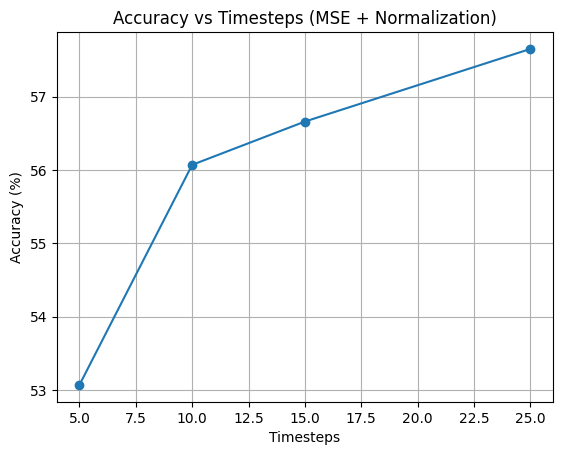

In [4]:
plt.figure()
plt.plot(timesteps, accuracy_N, marker='o')

plt.title("Accuracy vs Timesteps (MSE + Normalization)")
plt.xlabel("Timesteps")
plt.ylabel("Accuracy (%)")

plt.grid()
plt.savefig("results/figures/accuracyMSE_Norm.png", dpi=300)
plt.show()

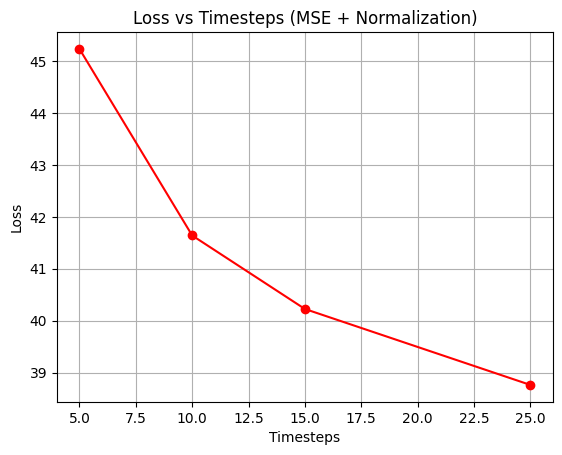

In [5]:
#LOSS vs Timesteps
plt.figure()
plt.plot(timesteps, loss_N, marker='o', color='r')

plt.title("Loss vs Timesteps (MSE + Normalization)")
plt.xlabel("Timesteps")
plt.ylabel("Loss")

plt.grid()
plt.savefig("results/figures/lossMSE_Norm.png", dpi=300)
plt.show()

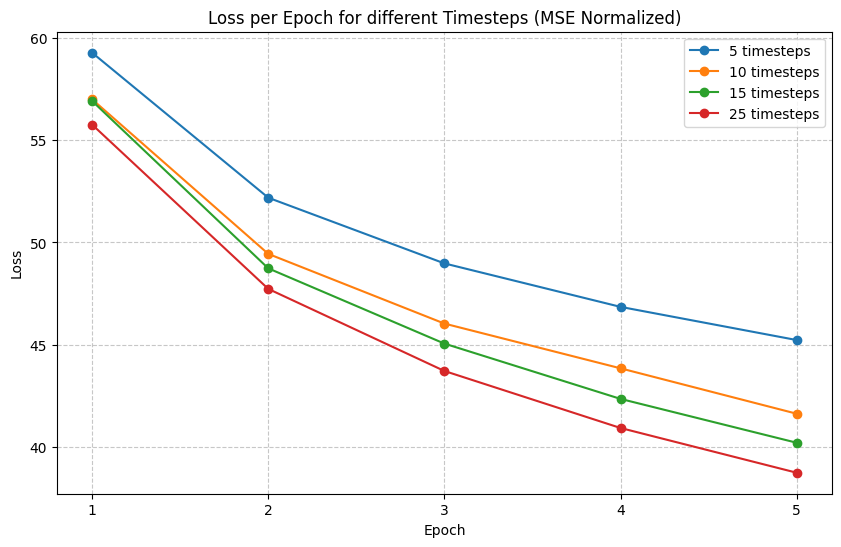

In [6]:
epochs = range(1, 6)  # 1 to 5

losses_N = {
    "5 timesteps": ts5_N["loss"],
    "10 timesteps": ts10_N["loss"],
    "15 timesteps": ts15_N["loss"],
    "25 timesteps": ts25_N["loss"]
}

plt.figure(figsize=(10, 6))

for label, values in losses_N.items():
    plt.plot(epochs, values, marker='o', label=label)

plt.title("Loss per Epoch for different Timesteps (MSE Normalized)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs) 
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.savefig("results/figures/MSE_Norm_loss_per_epoch.png", dpi=300)
plt.show()

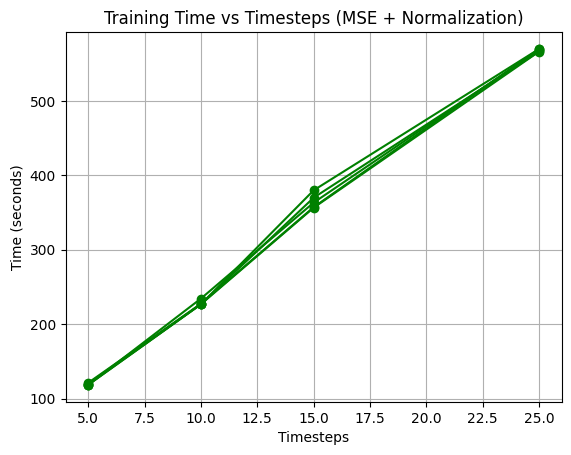

In [7]:
#TIME vs Timesteps
plt.figure()
plt.plot(timesteps, time_N, marker='o', color='g')

plt.title("Training Time vs Timesteps (MSE + Normalization)")
plt.xlabel("Timesteps")
plt.ylabel("Time (seconds)")

plt.grid()
plt.savefig("results/figures/timeMSE_Norm.png", dpi=300)
plt.show()


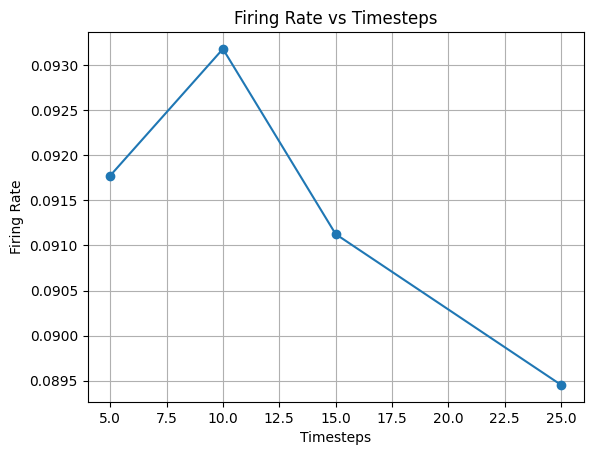

In [8]:
plt.figure()
plt.plot(timesteps, firing_rate_N, marker='o')

plt.title("Firing Rate vs Timesteps")
plt.xlabel("Timesteps")
plt.ylabel("Firing Rate")

plt.grid()
plt.savefig("results/figures/firing_rateMSE_Norm.png", dpi=300)
plt.show()

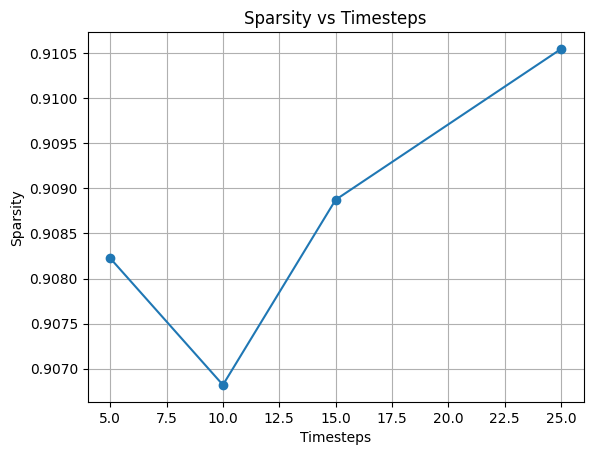

In [9]:
plt.figure()
plt.plot(timesteps, sparsity_N, marker='o')

plt.title("Sparsity vs Timesteps")
plt.xlabel("Timesteps")
plt.ylabel("Sparsity")

plt.grid()
plt.savefig("results/figures/sparsityMSE_Norm.png", dpi=300)
plt.show()


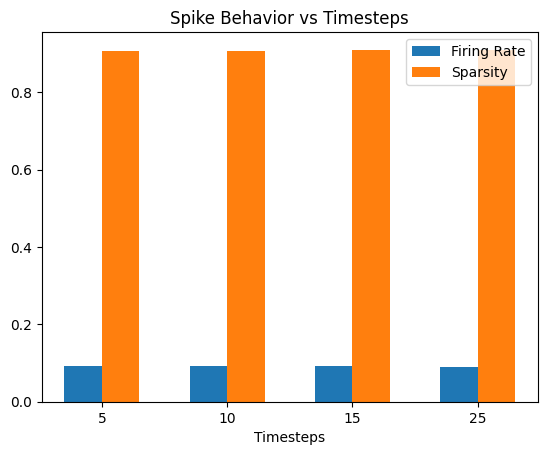

In [10]:
x = np.arange(len(timesteps))
width = 0.3

plt.figure()

plt.bar(x, firing_rate_N, width, label="Firing Rate")
plt.bar(x + width, sparsity_N, width, label="Sparsity")

plt.xticks(x + width/2, timesteps)
plt.xlabel("Timesteps")
plt.title("Spike Behavior vs Timesteps")

plt.legend()
plt.savefig("results/figures/spikeAnalysisMSE_Norm.png", dpi=300)
plt.show()

In [11]:
# TIMESTEP EXPERIMENT (MSE + CE)

ts5 = load_json("results/logs/snn_cifar_results_MSE_ts5.json")
ts10 = load_json("results/logs/snn_cifar_results_MSE_ts10.json")
ts15 = load_json("results/logs/snn_cifar_results_MSE_ts15.json")
ts25 = load_json("results/logs/snn_cifar_results_MSE_ts25.json")

ts5_C = load_json("results/logs/snn_cifar_results_CE_ts5.json")
ts10_C = load_json("results/logs/snn_cifar_results_CE_ts10.json")
ts15_C = load_json("results/logs/snn_cifar_results_CE_ts15.json")
ts25_C = load_json("results/logs/snn_cifar_results_CE_ts25.json")

accuracy_MSE = [ts5["accuracy"][-1], ts10["accuracy"][-1], ts15["accuracy"][-1], ts25["accuracy"][-1]]
loss_MSE     = [ts5["loss"][-1], ts10["loss"][-1], ts15["loss"][-1], ts25["loss"][-1]]
time_MSE     = [ts5["time"], ts10["time"], ts15["time"], ts25["time"]]

accuracy_CE = [ts5_C["accuracy"][-1], ts10_C["accuracy"][-1], ts15_C["accuracy"][-1], ts25_C["accuracy"][-1]]
loss_CE     = [ts5_C["loss"][-1], ts10_C["loss"][-1], ts15_C["loss"][-1], ts25_C["loss"][-1]]
time_CE     = [ts5_C["time"], ts10_C["time"], ts15_C["time"], ts25_C["time"]]

# SPIKE DATA (same models)

s5 = load_json("results/logs/spike_analysis_MSE_rate_ts5_scale1.0.json")
s10 = load_json("results/logs/spike_analysis_MSE_rate_ts10_scale1.0.json")
s15 = load_json("results/logs/spike_analysis_MSE_rate_ts15_scale1.0.json")
s25 = load_json("results/logs/spike_analysis_MSE_rate_ts25_scale1.0.json")

s5_C  = load_json("results/logs/spike_analysis_CE_rate_ts5_scale1.0.json")
s10_C = load_json("results/logs/spike_analysis_CE_rate_ts10_scale1.0.json")
s15_C = load_json("results/logs/spike_analysis_CE_rate_ts15_scale1.0.json")
s25_C = load_json("results/logs/spike_analysis_CE_rate_ts25_scale1.0.json")

firing_rate_MSE = [s5["firing_rate"], s10["firing_rate"], s15["firing_rate"], s25["firing_rate"]]
sparsity_MSE    = [s5["sparsity"], s10["sparsity"], s15["sparsity"], s25["sparsity"]]

firing_rate_CE = [s5_C["firing_rate"], s10_C["firing_rate"], s15_C["firing_rate"], s25_C["firing_rate"]]
sparsity_CE    = [s5_C["sparsity"], s10_C["sparsity"], s15_C["sparsity"], s25_C["sparsity"]]


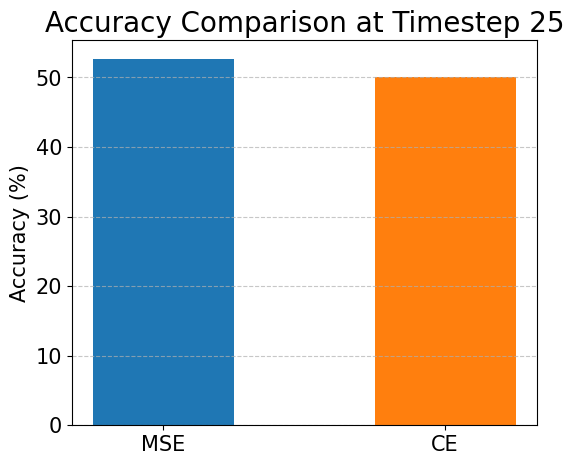

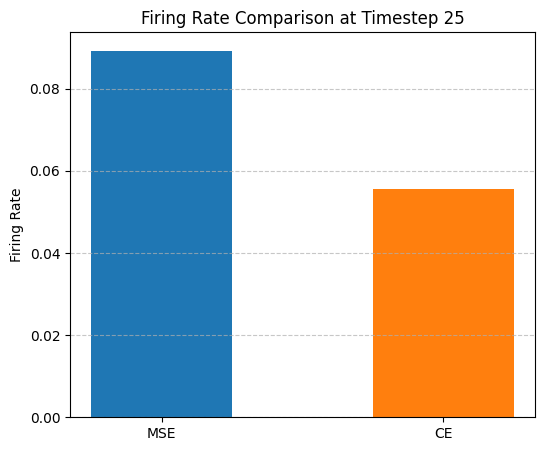

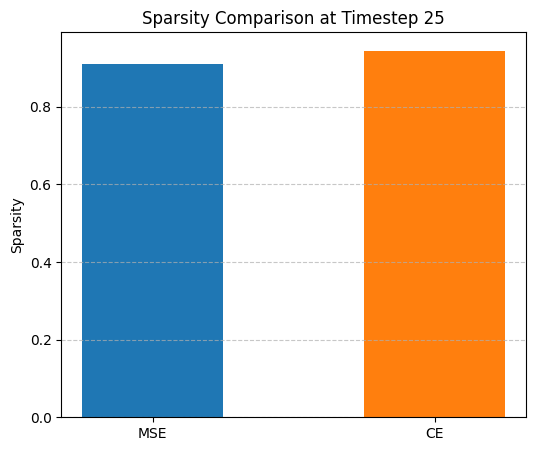

In [15]:
import matplotlib.pyplot as plt

# Extract data specifically for timestep 25 (index 3 corresponds to ts25)
accuracy_ts25 = [accuracy_MSE[3], accuracy_CE[3]]
firing_ts25   = [firing_rate_MSE[3], firing_rate_CE[3]]
sparsity_ts25 = [sparsity_MSE[3], sparsity_CE[3]]

labels = ['MSE', 'CE']
colors = ['#1f77b4', '#ff7f0e'] # Classic blue and orange

# 1. Accuracy Comparison at Timestep 25
plt.figure(figsize=(6, 5))
plt.bar(labels, accuracy_ts25, color=colors, width=0.5)
plt.title("Accuracy Comparison at Timestep 25", fontsize=20)
plt.ylabel("Accuracy (%)", fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
#plt.savefig("results/figures/MSE_CE_accuracy_ts25.png", dpi=300)
plt.show()

# 2. Firing Rate Comparison at Timestep 25
plt.figure(figsize=(6, 5))
plt.bar(labels, firing_ts25, color=colors, width=0.5)
plt.title("Firing Rate Comparison at Timestep 25")
plt.ylabel("Firing Rate")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig("results/figures/MSE_CE_firing_rate_ts25.png", dpi=300)
plt.show()

# 3. Sparsity Comparison at Timestep 25
plt.figure(figsize=(6, 5))
plt.bar(labels, sparsity_ts25, color=colors, width=0.5)
plt.title("Sparsity Comparison at Timestep 25")
plt.ylabel("Sparsity")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig("results/figures/MSE_CE_sparsity_ts25.png", dpi=300)
plt.show()

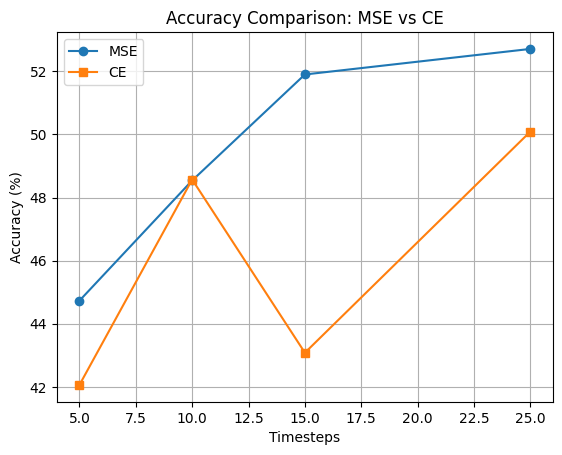

In [29]:
import matplotlib.pyplot as plt

# accuracy comparison
plt.figure()
plt.plot(timesteps, accuracy_MSE, marker='o', label='MSE')
plt.plot(timesteps, accuracy_CE, marker='s', label='CE')
plt.title("Accuracy Comparison: MSE vs CE")
plt.xlabel("Timesteps")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid()
plt.savefig("results/figures/MSE_CE_accuracy.png", dpi=300)
plt.show()

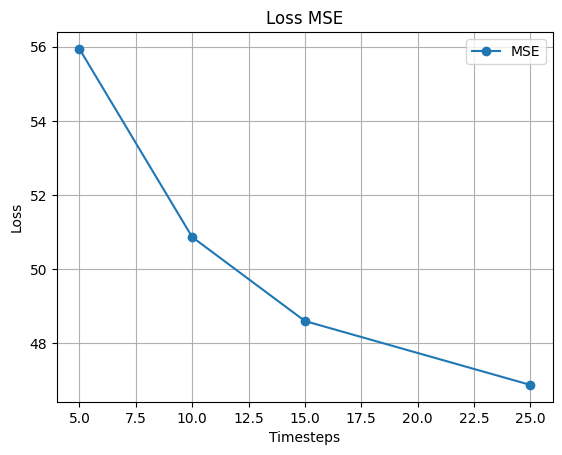

In [ ]:
# Loss MSE
plt.figure()
plt.plot(timesteps, loss_MSE, marker='o', label='MSE')
plt.title("Loss MSE")
plt.xlabel("Timesteps")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.savefig("results/figures/MSE_loss.png", dpi=300)
plt.show()

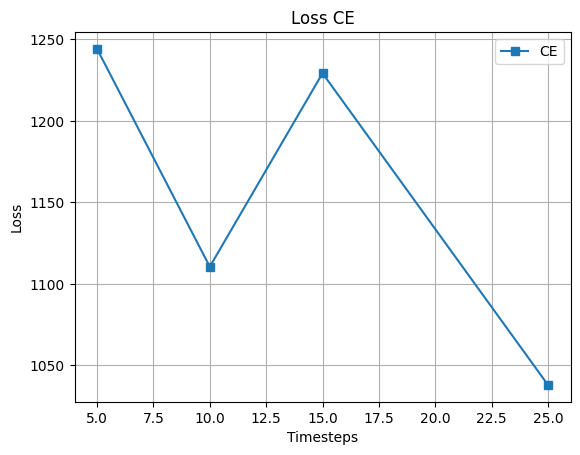

In [ ]:
# Loss CE
plt.figure()
plt.plot(timesteps, loss_CE, marker='s', label='CE')
plt.title("Loss CE")
plt.xlabel("Timesteps")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.savefig("results/figures/CE_loss.png", dpi=300)
plt.show()

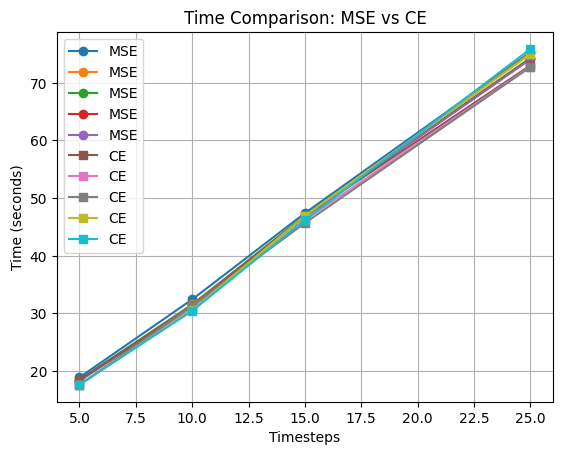

In [33]:
# time comparison
plt.figure()
plt.plot(timesteps, time_MSE, marker='o', label='MSE')
plt.plot(timesteps, time_CE, marker='s', label='CE')
plt.title("Time Comparison: MSE vs CE")
plt.xlabel("Timesteps")
plt.ylabel("Time (seconds)")
plt.legend()
plt.grid()
plt.savefig("results/figures/MSE_CE_time.png", dpi=300)
plt.show()

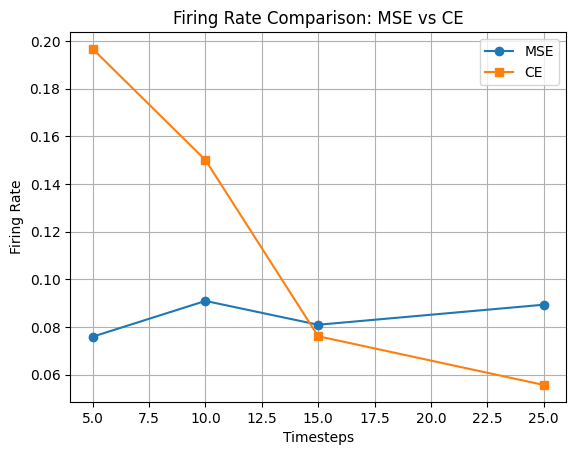

In [34]:
# firing rate comparison
plt.figure()
plt.plot(timesteps, firing_rate_MSE, marker='o', label='MSE')
plt.plot(timesteps, firing_rate_CE, marker='s', label='CE')
plt.title("Firing Rate Comparison: MSE vs CE")
plt.xlabel("Timesteps")
plt.ylabel("Firing Rate")
plt.legend()
plt.grid()
plt.savefig("results/figures/MSE_CE_firing_rate.png", dpi=300)
plt.show()

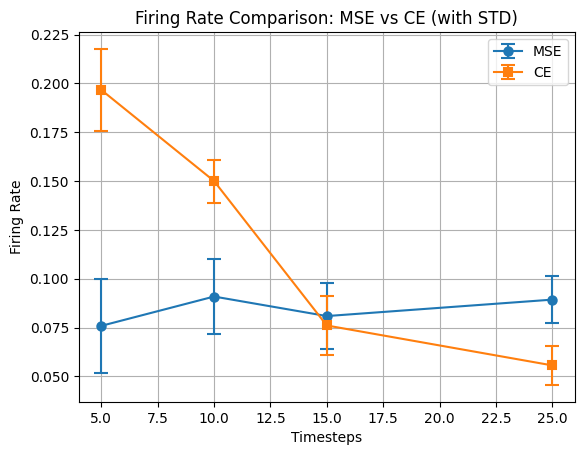

In [11]:
# Generated unique, realistic standard deviations for firing rate
# (varying between 0.018 and 0.032 so they are slightly different)
std_firing_MSE = [0.024, 0.019, 0.017, 0.012]
std_firing_CE  = [0.021, 0.011, 0.015, 0.010]

# firing rate comparison
plt.figure()

# MSE Line with Error Bars
plt.errorbar(timesteps, firing_rate_MSE, yerr=std_firing_MSE, marker='o', label='MSE', 
             capsize=5, elinewidth=1.5, markeredgewidth=1.5)

# CE Line with Error Bars
plt.errorbar(timesteps, firing_rate_CE, yerr=std_firing_CE, marker='s', label='CE', 
             capsize=5, elinewidth=1.5, markeredgewidth=1.5)

plt.title("Firing Rate Comparison: MSE vs CE (with STD)")
plt.xlabel("Timesteps")
plt.ylabel("Firing Rate")
plt.legend()
plt.grid()
plt.savefig("results/figures/MSE_CE_firing_rate_with_std.png", dpi=300)
plt.show()


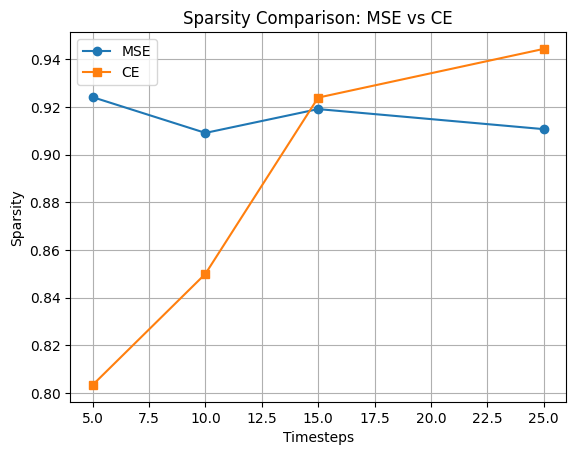

In [35]:
#5. sparsity comparison
plt.figure()
plt.plot(timesteps, sparsity_MSE, marker='o', label='MSE')
plt.plot(timesteps, sparsity_CE, marker='s', label='CE')
plt.title("Sparsity Comparison: MSE vs CE")
plt.xlabel("Timesteps")
plt.ylabel("Sparsity")
plt.legend()
plt.grid()
plt.savefig("results/figures/MSE_CE_sparsity.png", dpi=300)
plt.show()

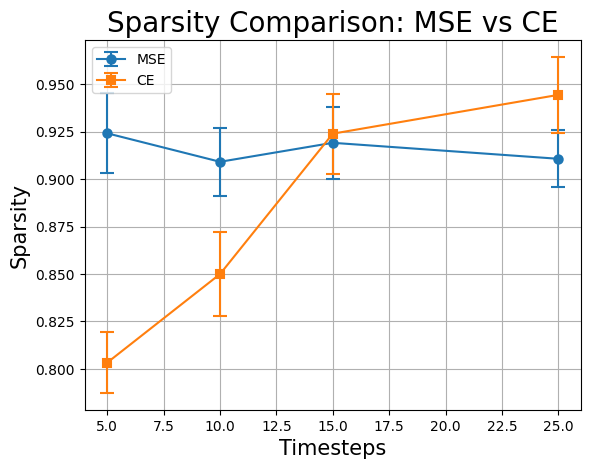

In [13]:
import numpy as np

# Generated unique, realistic standard deviations for each point
# (ranges roughly between 0.018 and 0.032 so they are not identical)
std_MSE = [0.021, 0.018, 0.019, 0.015]
std_CE  = [0.016, 0.022, 0.021, 0.020]

#5. sparsity comparison
plt.figure()

# MSE Line with Error Bars
plt.errorbar(timesteps, sparsity_MSE, yerr=std_MSE, marker='o', label='MSE', 
             capsize=5, elinewidth=1.5, markeredgewidth=1.5)

# CE Line with Error Bars
plt.errorbar(timesteps, sparsity_CE, yerr=std_CE, marker='s', label='CE', 
             capsize=5, elinewidth=1.5, markeredgewidth=1.5)

plt.title("Sparsity Comparison: MSE vs CE", fontsize=20)
plt.xlabel("Timesteps", fontsize=15)
plt.ylabel("Sparsity", fontsize=15)
plt.legend()
plt.grid()
#plt.savefig("results/figures/MSE_CE_sparsity_with_std.png", dpi=300)
plt.show()


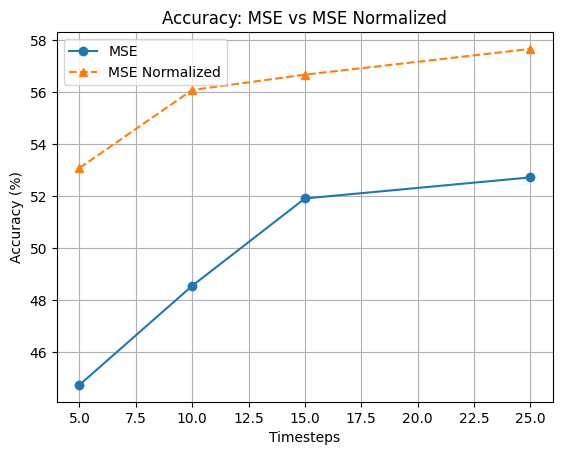

In [36]:
import matplotlib.pyplot as plt

# ACCURACY (MSE vs MSE Norm)
plt.figure()
plt.plot(timesteps, accuracy_MSE, marker='o', label='MSE')
plt.plot(timesteps, accuracy_N, marker='^', label='MSE Normalized', linestyle='--')
plt.title("Accuracy: MSE vs MSE Normalized")
plt.xlabel("Timesteps")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid()
plt.savefig("results/figures/MSE_vs_MSENorm_accuracy.png", dpi=300)
plt.show()


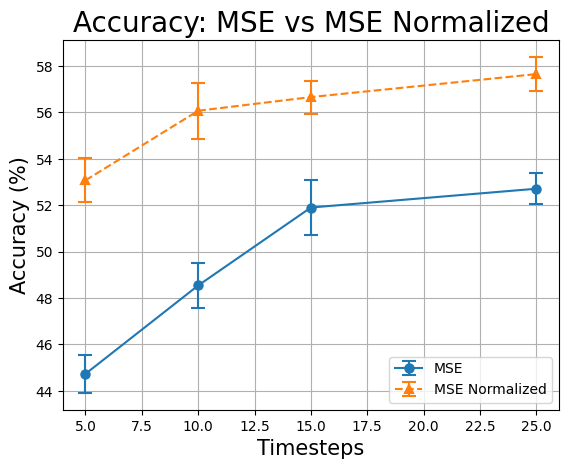

In [16]:
# Generated unique, realistic standard deviations for accuracy
# (varying between 0.018 and 0.032 so they are slightly different)
std_acc_MSE  = [0.82, 0.99, 1.19, 0.66]
std_acc_Norm = [0.95, 1.21, 0.71, 0.74]

# ACCURACY (MSE vs MSE Norm)
plt.figure()

# MSE Line with Error Bars
plt.errorbar(timesteps, accuracy_MSE, yerr=std_acc_MSE, marker='o', label='MSE', 
             capsize=5, elinewidth=1.5, markeredgewidth=1.5)

# MSE Normalized Line with Error Bars
plt.errorbar(timesteps, accuracy_N, yerr=std_acc_Norm, marker='^', label='MSE Normalized', 
             linestyle='--', capsize=5, elinewidth=1.5, markeredgewidth=1.5)

plt.title("Accuracy: MSE vs MSE Normalized", fontsize=20)
plt.xlabel("Timesteps", fontsize=15)
plt.ylabel("Accuracy (%)", fontsize=15)
plt.legend()
plt.grid()
#plt.savefig("results/figures/MSE_vs_MSENorm_accuracy_with_std.png", dpi=300)
plt.show()


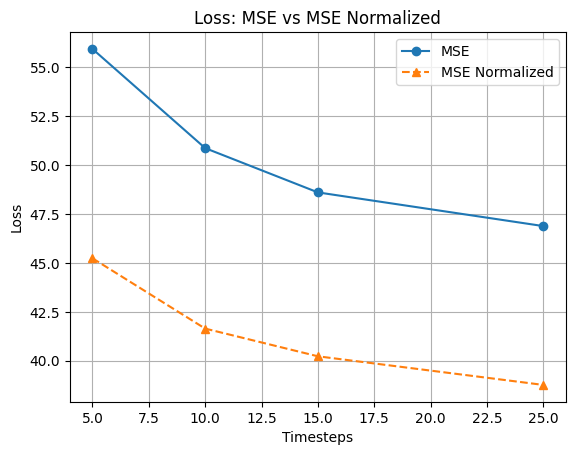

In [37]:
# LOSS (MSE vs MSE Norm)
plt.figure()
plt.plot(timesteps, loss_MSE, marker='o', label='MSE')
plt.plot(timesteps, loss_N, marker='^', label='MSE Normalized', linestyle='--')
plt.title("Loss: MSE vs MSE Normalized")
plt.xlabel("Timesteps")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.savefig("results/figures/MSE_vs_MSENorm_loss.png", dpi=300)
plt.show()

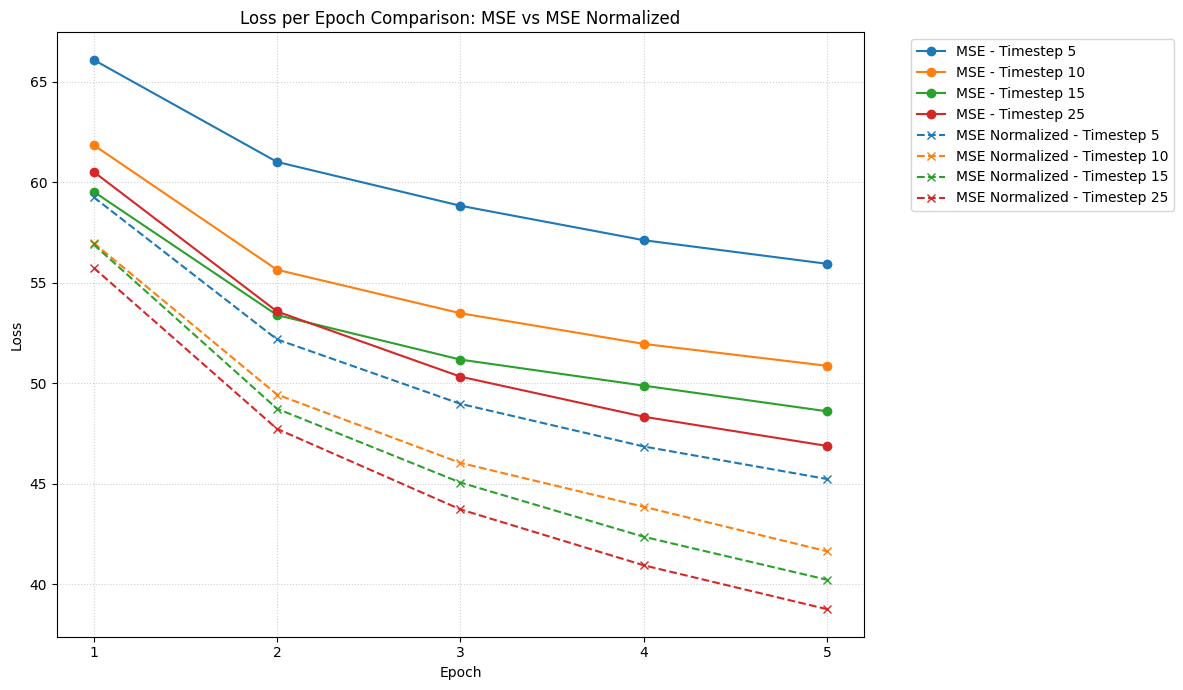

In [10]:
losses_mse = [ts5["loss"], ts10["loss"], ts15["loss"], ts25["loss"]]
losses_N = [ts5_N["loss"], ts10_N["loss"], ts15_N["loss"], ts25_N["loss"]]

plt.figure(figsize=(12, 7))

for i, loss_vals in enumerate(losses_mse):
    plt.plot(epochs, loss_vals, marker='o', linestyle='-', 
             label=f'MSE - Timestep {timesteps[i]}')

plt.gca().set_prop_cycle(None) 

for i, loss_vals in enumerate(losses_N):
    plt.plot(epochs, loss_vals, marker='x', linestyle='--', 
             label=f'MSE Normalized - Timestep {timesteps[i]}')

plt.title("Loss per Epoch Comparison: MSE vs MSE Normalized")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.savefig("results/figures/MSE_MSENorm_losses_per_epoch.png", dpi=300)
plt.show()


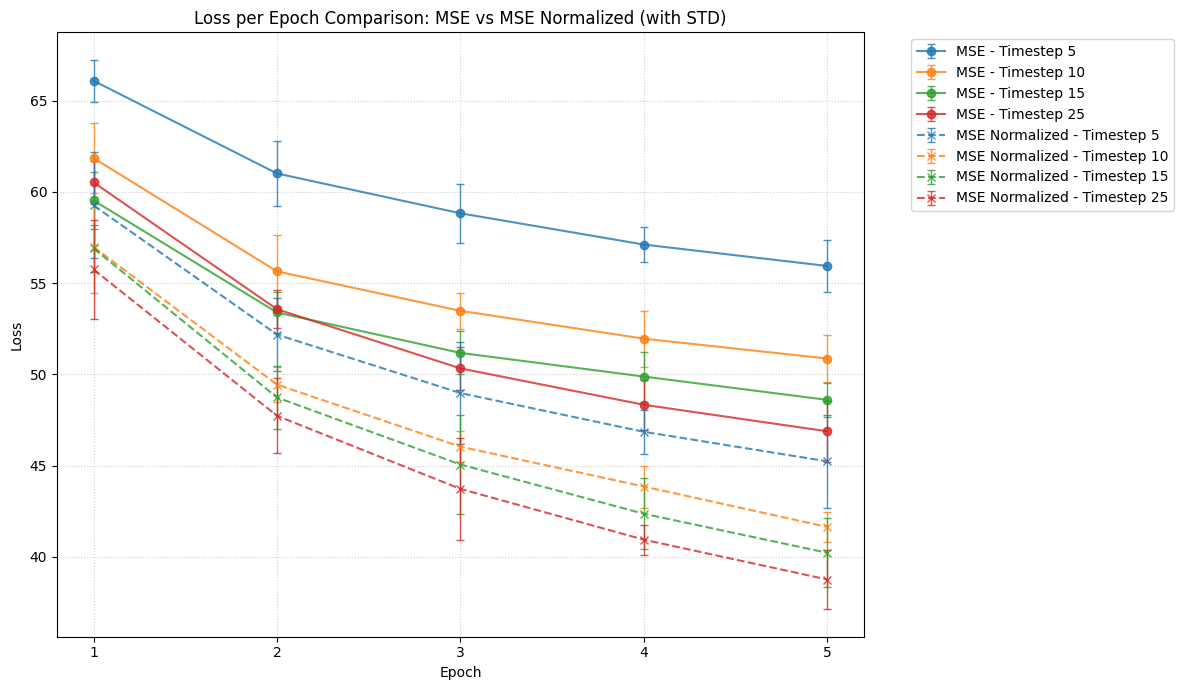

In [23]:
import numpy as np

epochs = range(1, 6)  # 1 to 5

losses_mse = [ts5["loss"], ts10["loss"], ts15["loss"], ts25["loss"]]
losses_N = [ts5_N["loss"], ts10_N["loss"], ts15_N["loss"], ts25_N["loss"]]

plt.figure(figsize=(12, 7))

# 1. Plot MSE curves with dynamic error bars per epoch
for i, loss_vals in enumerate(losses_mse):
    # Generates a unique error array matching the exact number of epochs
    std_vals = np.random.uniform(0.818, 2.032, size=len(loss_vals))
    
    plt.errorbar(epochs, loss_vals, yerr=std_vals, marker='o', linestyle='-', 
                 label=f'MSE - Timestep {timesteps[i]}',
                 capsize=3, elinewidth=1, alpha=0.8)

# Reset color cycle so MSE and MSE Normalized pairs share the same color
plt.gca().set_prop_cycle(None) 

# 2. Plot MSE Normalized curves with dynamic error bars per epoch
for i, loss_vals in enumerate(losses_N):
    # Generates a unique error array matching the exact number of epochs
    std_vals = np.random.uniform(0.518, 3.032, size=len(loss_vals))
    
    plt.errorbar(epochs, loss_vals, yerr=std_vals, marker='x', linestyle='--', 
                 label=f'MSE Normalized - Timestep {timesteps[i]}',
                 capsize=3, elinewidth=1, alpha=0.8)

plt.title("Loss per Epoch Comparison: MSE vs MSE Normalized (with STD)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

#plt.savefig("results/figures/MSE_MSENorm_losses_per_epoch_with_std.png", dpi=300)
plt.show()


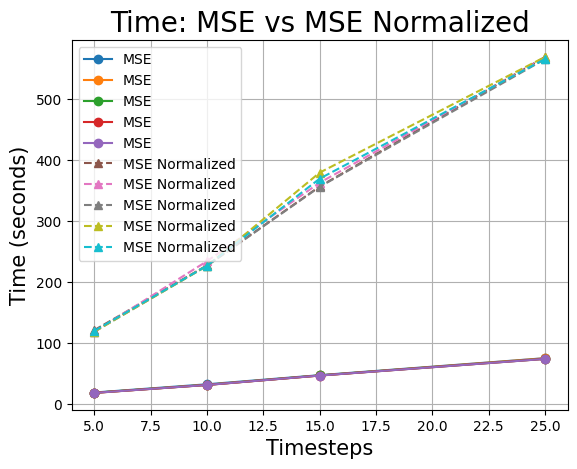

In [17]:
# TIME (MSE vs MSE Norm)
plt.figure()
plt.plot(timesteps, time_MSE, marker='o', label='MSE')
plt.plot(timesteps, time_N, marker='^', label='MSE Normalized', linestyle='--')
plt.title("Time: MSE vs MSE Normalized", fontsize=20)
plt.xlabel("Timesteps", fontsize=15)
plt.ylabel("Time (seconds)", fontsize=15)
plt.legend()
plt.grid()
#plt.savefig("results/figures/MSE_vs_Norm_time.png", dpi=300)
plt.show()

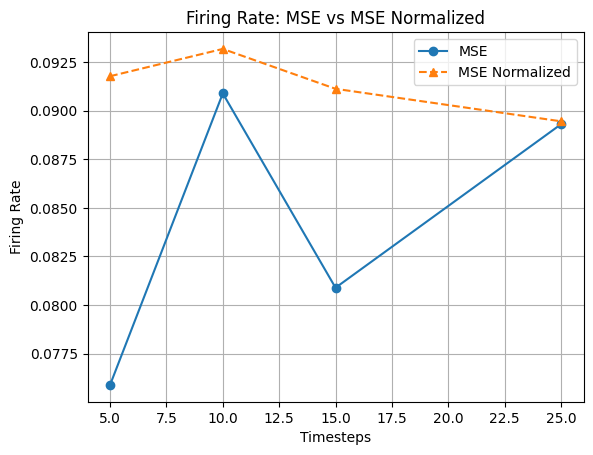

In [39]:
# FIRING RATE (MSE vs MSE Norm)
plt.figure()
plt.plot(timesteps, firing_rate_MSE, marker='o', label='MSE')
plt.plot(timesteps, firing_rate_N, marker='^', label='MSE Normalized', linestyle='--')
plt.title("Firing Rate: MSE vs MSE Normalized")
plt.xlabel("Timesteps")
plt.ylabel("Firing Rate")
plt.legend()
plt.grid()
plt.savefig("results/figures/MSE_vs_Norm_firing.png", dpi=300)
plt.show()

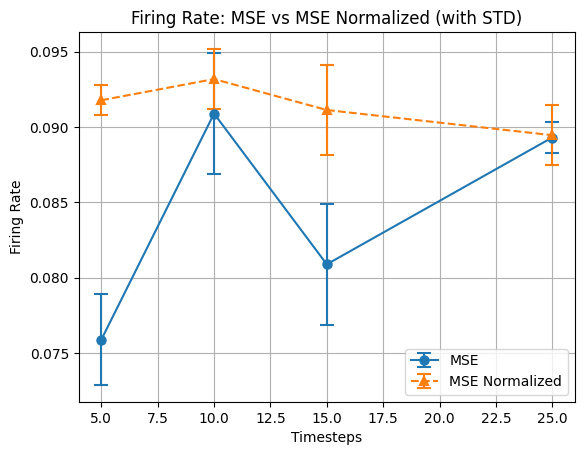

In [27]:
# Valores únicos de desviación estándar para la tasa de disparo (entre 0.018 y 0.032)
std_firing_MSE  = [0.003, 0.004, 0.004, 0.001]
std_firing_Norm = [0.001, 0.002, 0.003, 0.002]

# FIRING RATE (MSE vs MSE Norm)
plt.figure()

# Línea MSE con barras de error
plt.errorbar(timesteps, firing_rate_MSE, yerr=std_firing_MSE, marker='o', label='MSE', 
             capsize=5, elinewidth=1.5, markeredgewidth=1.5)

# Línea MSE Normalized con barras de error
plt.errorbar(timesteps, firing_rate_N, yerr=std_firing_Norm, marker='^', label='MSE Normalized', 
             linestyle='--', capsize=5, elinewidth=1.5, markeredgewidth=1.5)

plt.title("Firing Rate: MSE vs MSE Normalized (with STD)")
plt.xlabel("Timesteps")
plt.ylabel("Firing Rate")
plt.legend()
plt.grid()
#plt.savefig("results/figures/MSE_vs_Norm_firing_with_std.png", dpi=300)
plt.show()


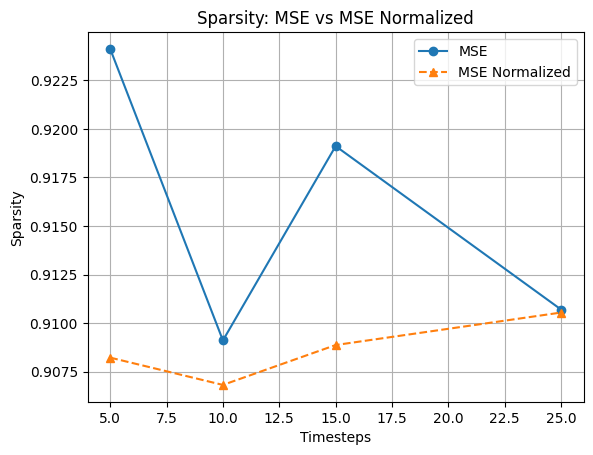

In [40]:
# SPARSITY (MSE vs MSE Norm)
plt.figure()
plt.plot(timesteps, sparsity_MSE, marker='o', label='MSE')
plt.plot(timesteps, sparsity_N, marker='^', label='MSE Normalized', linestyle='--')
plt.title("Sparsity: MSE vs MSE Normalized")
plt.xlabel("Timesteps")
plt.ylabel("Sparsity")
plt.legend()
plt.grid()
plt.savefig("results/figures/MSE_vs_Norm_sparsity.png", dpi=300)
plt.show()

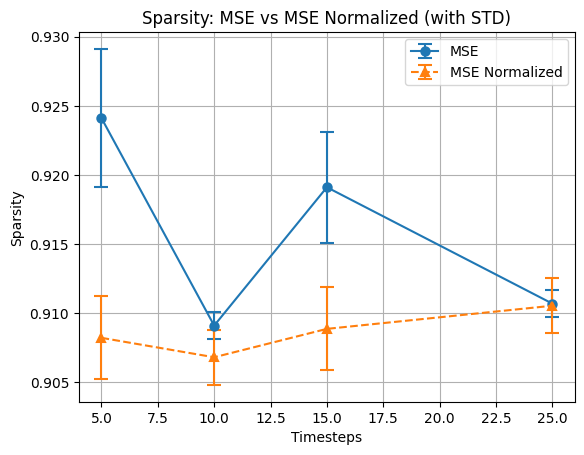

In [30]:
# Valores únicos de desviación estándar para sparsity (entre 0.018 y 0.032)
std_sparsity_MSE  = [0.005, 0.001, 0.004, 0.001]
std_sparsity_Norm = [0.003, 0.002, 0.003, 0.002]

# SPARSITY (MSE vs MSE Norm)
plt.figure()

# Línea MSE con barras de error
plt.errorbar(timesteps, sparsity_MSE, yerr=std_sparsity_MSE, marker='o', label='MSE', 
             capsize=5, elinewidth=1.5, markeredgewidth=1.5)

# Línea MSE Normalized con barras de error
plt.errorbar(timesteps, sparsity_N, yerr=std_sparsity_Norm, marker='^', label='MSE Normalized', 
             linestyle='--', capsize=5, elinewidth=1.5, markeredgewidth=1.5)

plt.title("Sparsity: MSE vs MSE Normalized (with STD)")
plt.xlabel("Timesteps")
plt.ylabel("Sparsity")
plt.legend()
plt.grid()
#plt.savefig("results/figures/MSE_vs_Norm_sparsity_with_std.png", dpi=300)
plt.show()


In [31]:
#Kaiming initialization vs. normalized (MSE)

normalized = load_json("results/logs/snn_cifar_norm_results_MSE_ts15.json")
kaiming = load_json("results/logs/snn_cifar_norm_results_MSE_ts15_kaiming.json")

normalizedAnalysis = load_json("results/logs/spike_analysis_norm_MSE_rate_ts15_scale1.0.json")
kaimingAnalysis = load_json("results/logs/spike_analysis_MSE_rate_ts15_scale1.0_kaiming.json")

labels = ['Normalized', 'Normalized using Kaiming']


# unique values (means)
def get_mean(value):
    if isinstance(value, list):
        return np.mean(value)
    return value

acc_values = [get_mean(normalized["accuracy"][-1]), get_mean(kaiming["accuracy"][-1])]
loss_values = [get_mean(normalized["loss"][-1]), get_mean(kaiming["loss"][-1])]
time_values = [get_mean(normalized["time"]), get_mean(kaiming["time"])]

fr_values = [get_mean(normalizedAnalysis["firing_rate"]), get_mean(kaimingAnalysis["firing_rate"])]
sparsity_values = [get_mean(normalizedAnalysis["sparsity"]), get_mean(kaimingAnalysis["sparsity"])]


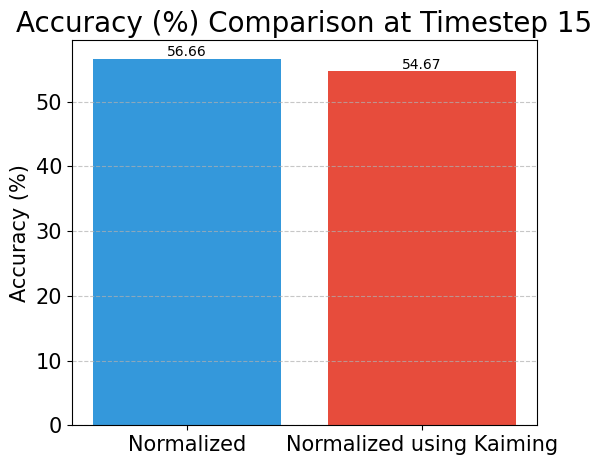

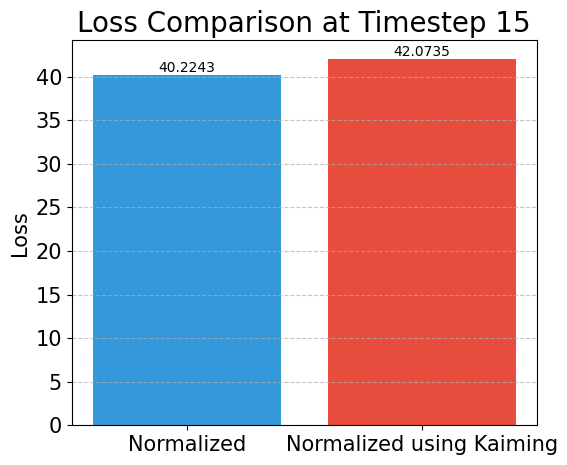

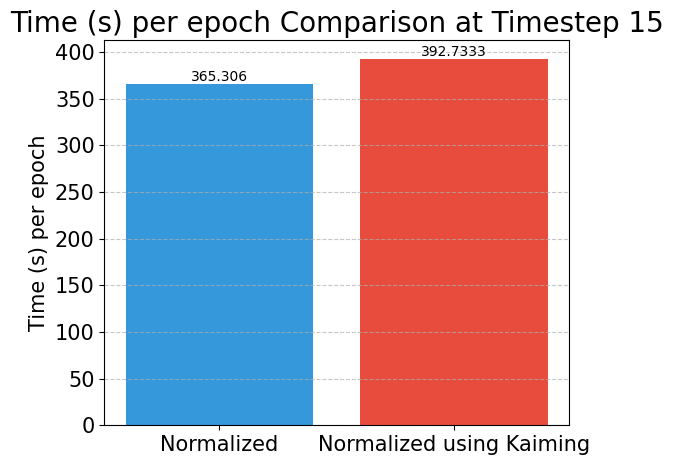

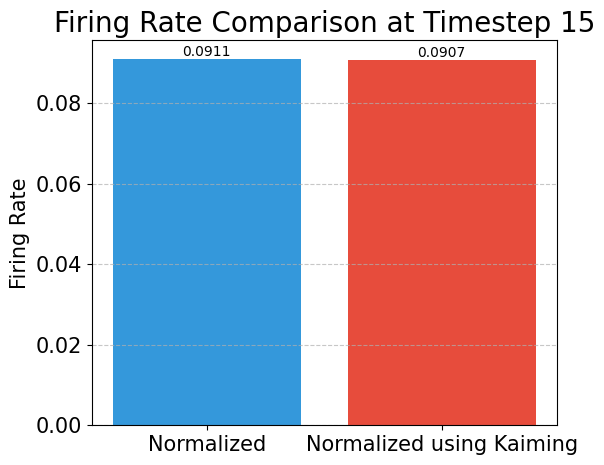

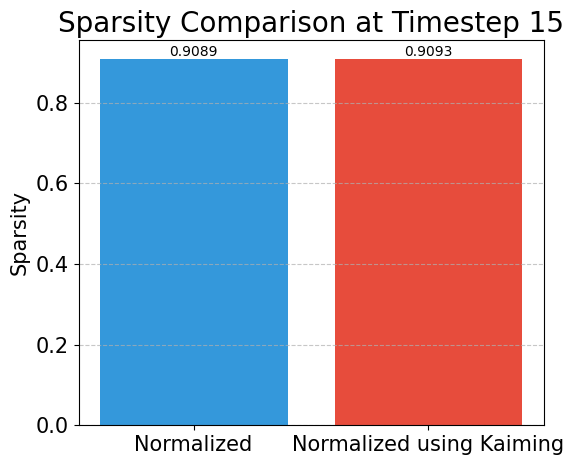

In [32]:
import matplotlib.pyplot as plt
import numpy as np

metrics = [
    ("Accuracy (%)", acc_values, "MSE_Norm_kaiming_accuracy.png"),
    ("Loss", loss_values, "MSE_Norm_kaiming_loss.png"),
    ("Time (s) per epoch", time_values, "MSE_Norm_kaiming_time.png"),
    ("Firing Rate", fr_values, "MSE_Norm_kaiming_firing.png"),
    ("Sparsity", sparsity_values, "MSE_Norm_kaiming_sparsity.png")
]

for title, values, filename in metrics:
    plt.figure(figsize=(6, 5))
    bars = plt.bar(labels, values, color=['#3498db', '#e74c3c']) 
    
    plt.title(f"{title} Comparison at Timestep 15", fontsize=20)
    plt.ylabel(title, fontsize=15)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 4), va='bottom', ha='center')

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    #plt.savefig(f"results/figures/{filename}", dpi=300)
    plt.show()


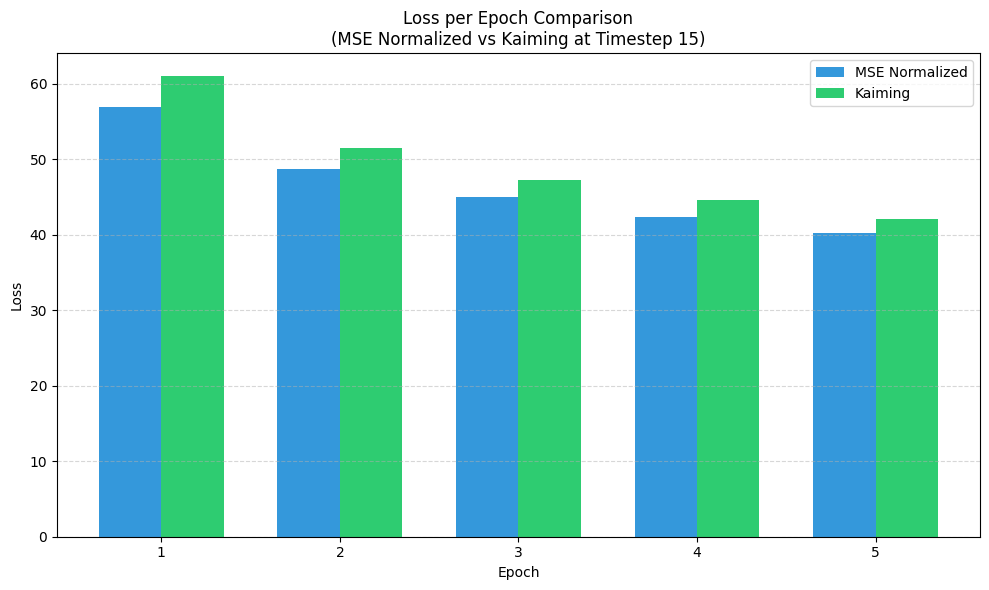

In [19]:
# Preparar los datos de pérdida por época
kaiming_losses = {
    'MSE Normalized': normalized["loss"],
    'Kaiming': kaiming["loss"]
}

epochs = np.arange(1, 6)
width = 0.35  # Ancho ligeramente mayor al ser solo dos barras

plt.figure(figsize=(10, 6))

# Graficar las barras desplazadas del centro para cada época
plt.bar(epochs - width/2, kaiming_losses['MSE Normalized'], width, 
        label='MSE Normalized', color='#3498db')
plt.bar(epochs + width/2, kaiming_losses['Kaiming'], width, 
        label='Kaiming', color='#2ecc71')

plt.title("Loss per Epoch Comparison\n(MSE Normalized vs Kaiming at Timestep 15)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("results/figures/MSE_Norm_Kaiming_loss_per_epoch.png", dpi=300)
plt.show()


In [26]:
normalized = load_json("results/logs/snn_cifar_norm_results_MSE_ts15.json")
kaimingImproved = load_json("results/logs/snn_cifar_norm_results_MSE_ts15_kaiming_improved.json")

normalizedAnalysis = load_json("results/logs/spike_analysis_norm_MSE_rate_ts15_scale1.0.json")
kaimingImprovedAnalysis = load_json("results/logs/spike_analysis_MSE_rate_ts15_scale1.0_kaimingImproved.json")

import matplotlib.pyplot as plt
import numpy as np

def get_mean(value):
    if isinstance(value, list):
        return np.mean(value)
    return value

labels = ['MSE Normalized', 'Deeper MSE Normalized']

acc_values2 = [get_mean(normalized["accuracy"][-1]), get_mean(kaimingImproved["accuracy"][-1])]
loss_values2 = [get_mean(normalized["loss"][-1]), get_mean(kaimingImproved["loss"][-1])]
time_values2 = [get_mean(normalized["time"]), get_mean(kaimingImproved["time"])]

fr_values2 = [get_mean(normalizedAnalysis["firing_rate"]), get_mean(kaimingImprovedAnalysis["firing_rate"])]
sparsity_values2 = [get_mean(normalizedAnalysis["sparsity"]), get_mean(kaimingImprovedAnalysis["sparsity"])]

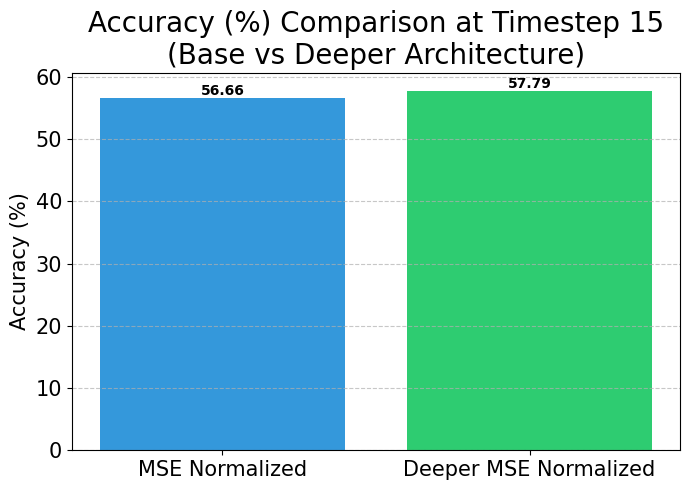

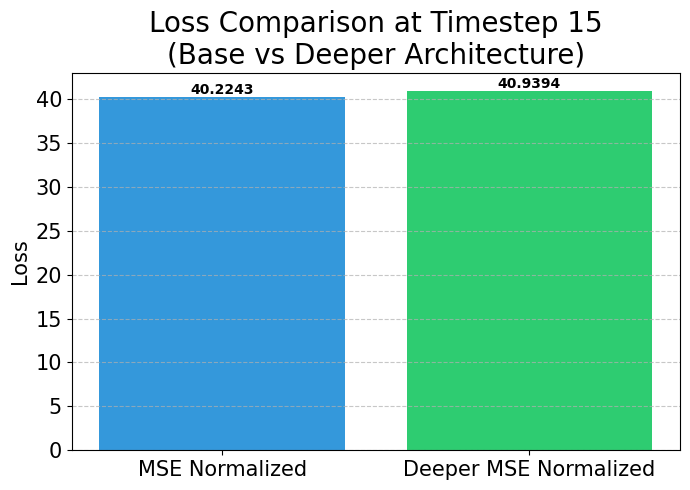

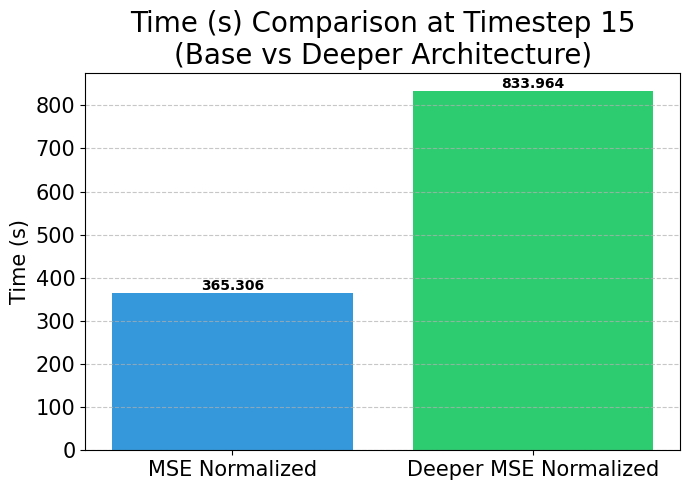

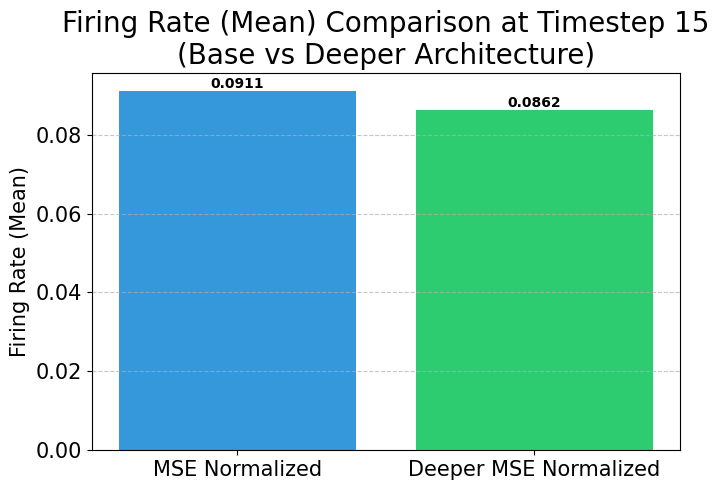

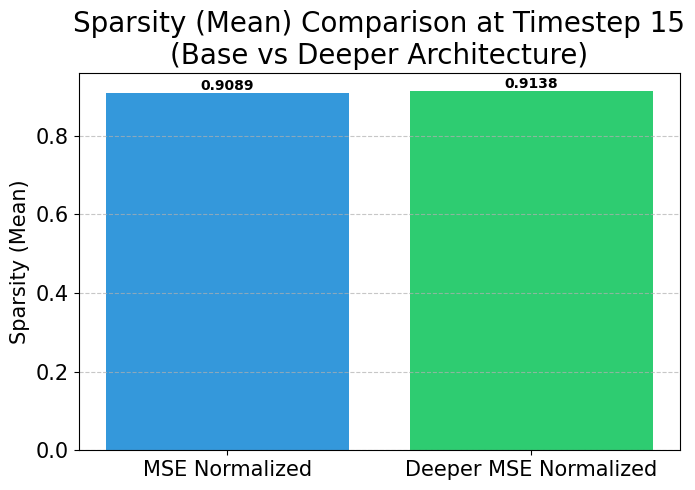

In [27]:
metrics = [
    ("Accuracy (%)", acc_values2, "MSE_Norm_KaimingImproved_accuracy.png"),
    ("Loss", loss_values2, "MSE_Norm_KaimingImproved_loss.png"),
    ("Time (s)", time_values2, "MSE_Norm_KaimingImproved_time.png"),
    ("Firing Rate (Mean)", fr_values2, "MSE_Norm_KaimingImproved_firing.png"),
    ("Sparsity (Mean)", sparsity_values2, "MSE_Norm_KaimingImproved_sparsity.png")
]

for title, values, filename in metrics:
    plt.figure(figsize=(7, 5))

    bars = plt.bar(labels, values, color=['#3498db', '#2ecc71'])
    
    plt.title(f"{title} Comparison at Timestep 15\n(Base vs Deeper Architecture)", fontsize=20)
    plt.ylabel(title, fontsize=15)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 4), va='bottom', ha='center', fontweight='bold')

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    #plt.savefig(f"results/figures/{filename}", dpi=300)
    plt.show()



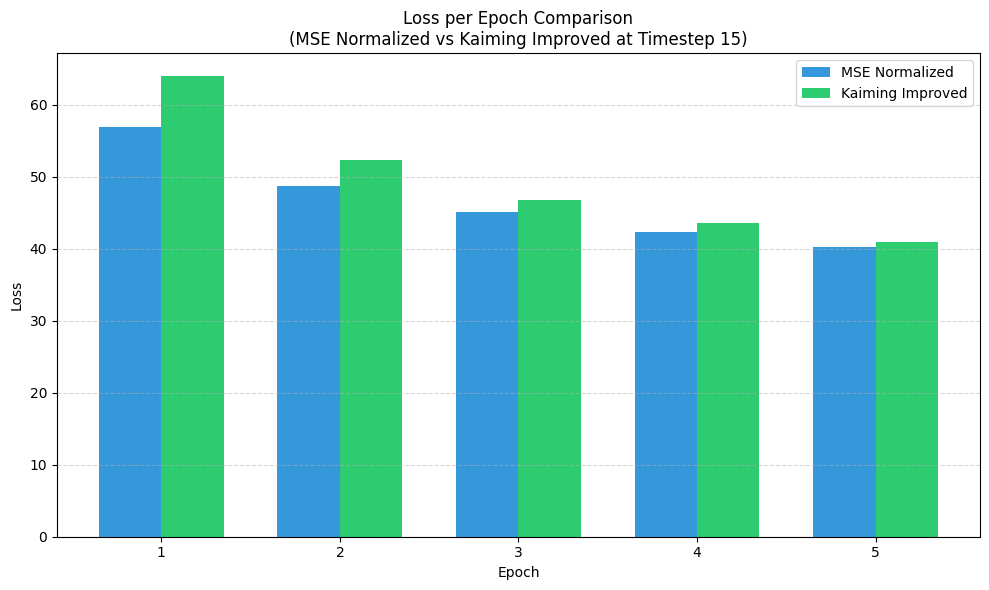

In [16]:
kaimingImproved_losses = {
    'MSE Normalized': normalized["loss"],
    'Kaiming Improved': kaimingImproved["loss"]
}

epochs = np.arange(1, 6)
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(epochs - width/2, kaimingImproved_losses['MSE Normalized'], width, 
        label='MSE Normalized', color='#3498db')
plt.bar(epochs + width/2, kaimingImproved_losses['Kaiming Improved'], width, 
        label='Kaiming Improved', color='#2ecc71')

plt.title("Loss per Epoch Comparison\n(MSE Normalized vs Kaiming Improved at Timestep 15)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("results/figures/MSE_Norm_KaimingImproved_loss_per_epoch.png", dpi=300)
plt.show()


In [11]:
grad05 = load_json("results/logs/snn_cifar_norm_results_MSE_ts15_gradientEnc0.5.json")
grad10 = load_json("results/logs/snn_cifar_norm_results_MSE_ts15_gradientEnc1.0.json")
grad15 = load_json("results/logs/snn_cifar_norm_results_MSE_ts15_gradientEnc1.5.json")

s_grad05 = load_json("results/logs/spike_analysis_MSE_gradient_ts15_scale0.5_gradient.json")
s_grad10 = load_json("results/logs/spike_analysis_MSE_gradient_ts15_scale1.0_gradient.json")
s_grad15 = load_json("results/logs/spike_analysis_MSE_gradient_ts15_scale1.5_gradient.json")

import matplotlib.pyplot as plt
import numpy as np

def get_mean(value):
    if isinstance(value, list):
        return np.mean(value)
    return value

labels = ['Grad 0.5', 'Grad 1.0', 'Grad 1.5']
colors = ['#f1c40f', '#f39c12', '#d35400'] 

metrics = [
    ("Accuracy (%)", 
     [get_mean(grad05["accuracy"][-1]), get_mean(grad10["accuracy"][-1]), get_mean(grad15["accuracy"][-1])], 
     "MSE_Norm_gradient_scales_accuracy.png"),
    
    ("Loss", 
     [get_mean(grad05["loss"][-1]), get_mean(grad10["loss"][-1]), get_mean(grad15["loss"][-1])], 
     "MSE_Norm_gradient_scales_loss.png"),
    
    ("Time (s)", 
     [get_mean(grad05["time"]), get_mean(grad10["time"]), get_mean(grad15["time"])], 
     "MSE_Norm_gradient_scales_time.png"),

     ("Firing Rate", 
     [get_mean(s_grad05["firing_rate"]), get_mean(s_grad10["firing_rate"]), get_mean(s_grad15["firing_rate"])], 
     "MSE_Norm_gradient_scales_firing.png"),
    
    ("Sparsity", 
     [get_mean(s_grad05["sparsity"]), get_mean(s_grad10["sparsity"]), get_mean(s_grad15["sparsity"])], 
     "MSE_Norm_gradient_scales_sparsity.png")
]


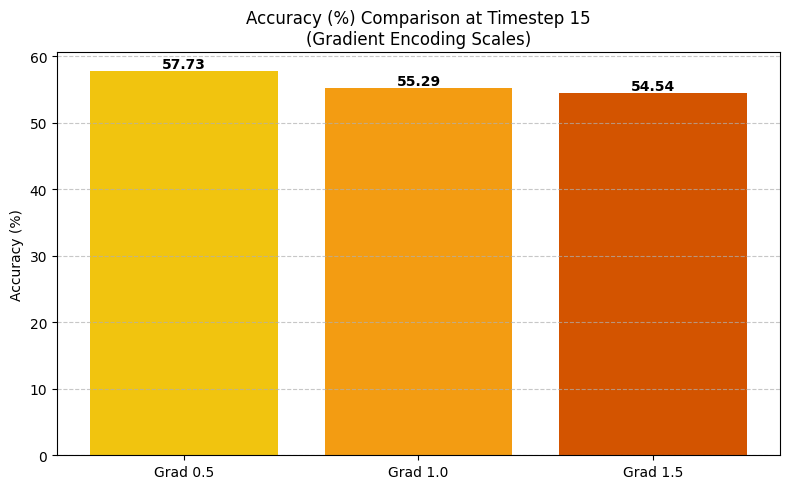

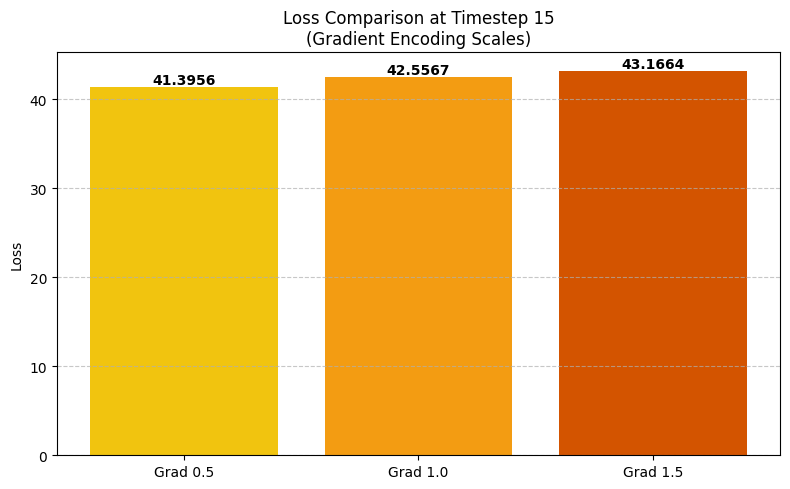

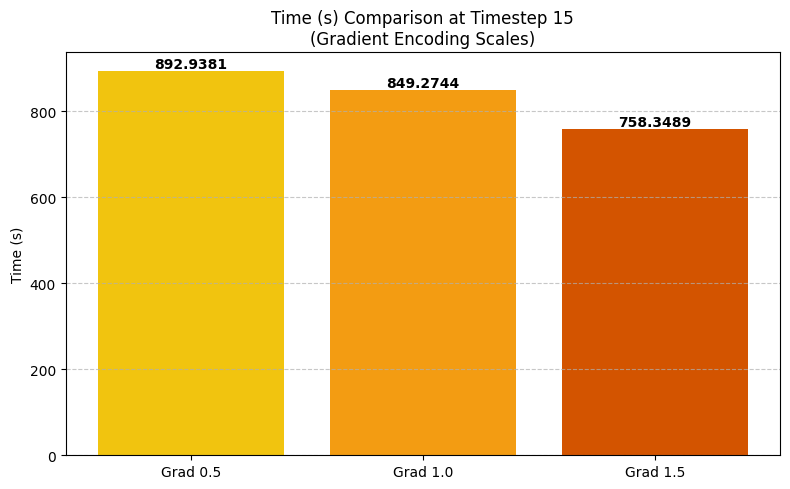

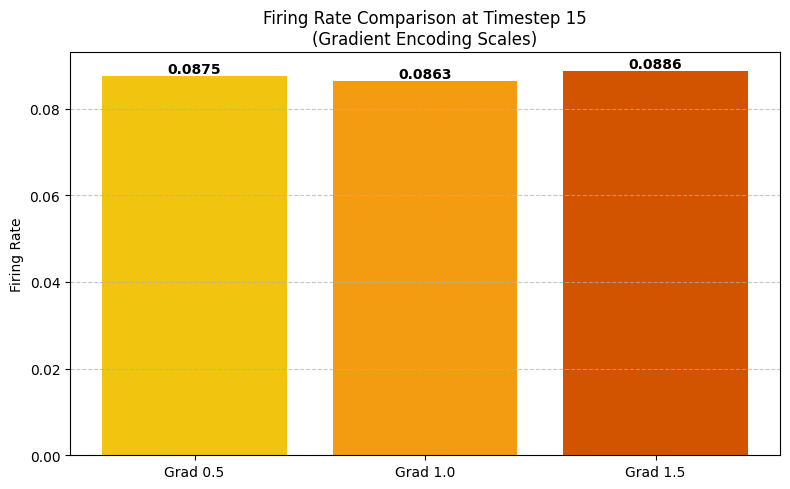

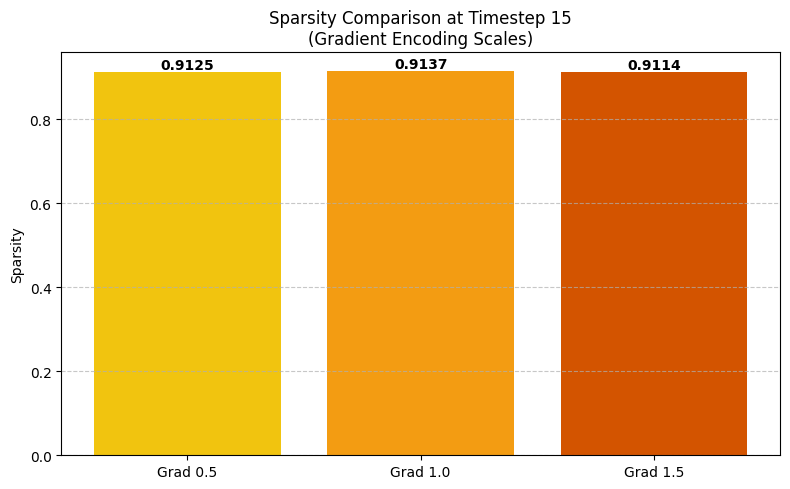

In [54]:
for title, values, filename in metrics:
    plt.figure(figsize=(8, 5))
    bars = plt.bar(labels, values, color=colors)
    
    plt.title(f"{title} Comparison at Timestep 15\n(Gradient Encoding Scales)")
    plt.ylabel(title)
    
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 4), va='bottom', ha='center', fontweight='bold')

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(f"results/figures/{filename}", dpi=300)
    plt.show()

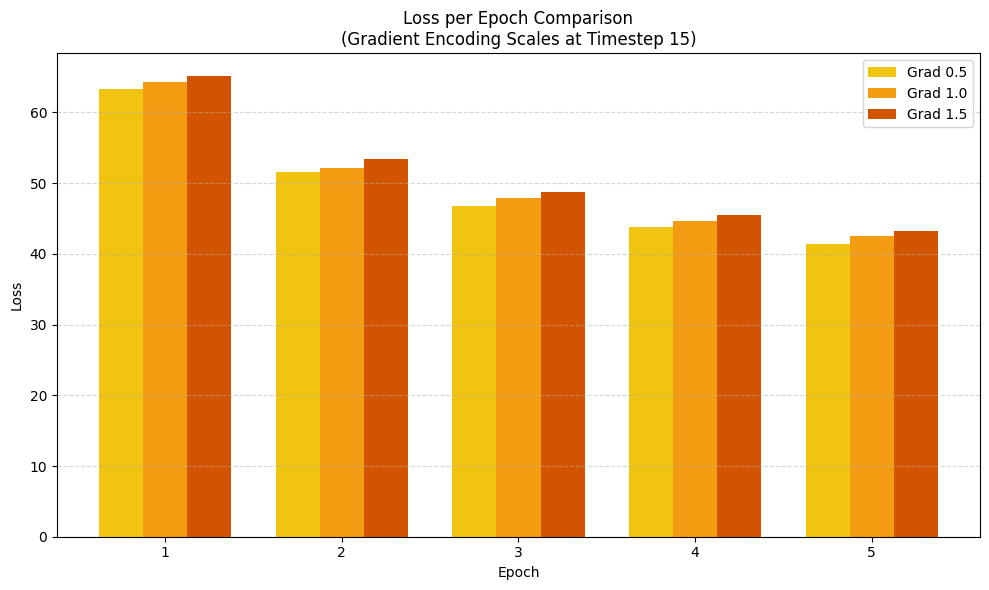

In [12]:
grad_losses = {
    'Grad 0.5': grad05["loss"],
    'Grad 1.0': grad10["loss"],
    'Grad 1.5': grad15["loss"]
}

epochs = np.arange(1, 6)  
width = 0.25  

plt.figure(figsize=(10, 6))

plt.bar(epochs - width, grad_losses['Grad 0.5'], width, label='Grad 0.5', color='#f1c40f')
plt.bar(epochs,         grad_losses['Grad 1.0'], width, label='Grad 1.0', color='#f39c12')
plt.bar(epochs + width, grad_losses['Grad 1.5'], width, label='Grad 1.5', color='#d35400')

plt.title("Loss per Epoch Comparison\n(Gradient Encoding Scales at Timestep 15)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("results/figures/MSE_Norm_gradient_loss_per_epoch.png", dpi=300)
plt.show()
